# Agricultural Risk Prediction

In [38]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report

import matplotlib.pyplot as plt
df = pd.read_csv("data/final/agri_combined_dataset.csv")  

df.head()

,state,district,crop,year,area,production,yield,annual_rainfall,n_high,n_medium,...,k_medium,k_low,oc_high,oc_medium,oc_low,ph_alkaline,ph_acidic,ph_neutral,ec_nonsaline,ec_saline
0,andhra pradesh,alluri sitharama raju,Cotton(lint),2022,2682.0,7614.0,2.84,NaN,3.26,54.11,...,44.99,29.87,27.25,64.48,8.27,0.12,18.93,80.95,99.81,0.19
1,andhra pradesh,anakapalli,Cotton(lint),2022,82.0,230.0,2.80,NaN,12.10,25.02,...,22.88,8.79,12.98,25.62,61.40,0.62,0.10,99.27,98.99,1.01
2,andhra pradesh,anantapur,Cotton(lint),2012,28000.0,35000.0,1.25,536,0.06,11.63,...,27.33,1.74,4.00,11.80,84.21,0.88,0.02,99.10,99.61,0.39
3,andhra pradesh,anantapur,Cotton(lint),2013,37661.0,77316.0,2.05,501.7,0.06,11.63,...,27.33,1.74,4.00,11.80,84.21,0.88,0.02,99.10,99.61,0.39
4,andhra pradesh,anantapur,Cotton(lint),2014,73734.0,103779.0,1.41,437.8,0.06,11.63,...,27.33,1.74,4.00,11.80,84.21,0.88,0.02,99.10,99.61,0.39


# Dataset with Mean+Std+CV+CV Norm+Risk

In [39]:
df.replace(['—', '-', 'NA', 'N/A', ''], np.nan, inplace=True)
df['yield'] = pd.to_numeric(df['yield'], errors='coerce')

if 'Rainfall' in df.columns:
    df['Rainfall'] = pd.to_numeric(df['Rainfall'], errors='coerce')
df = df.dropna(subset=['yield'])
grouped = df.groupby(['state', 'crop'])
model_df = grouped['yield'].agg(['mean', 'std']).reset_index()
model_df.columns = ['state', 'crop', 'mean', 'std']
model_df['CV'] = model_df['std'] / model_df['mean']
cv_min = model_df['CV'].min()
cv_max = model_df['CV'].max()
model_df['CV_norm'] = (model_df['CV'] - cv_min) / (cv_max - cv_min)
model_df['Risk'] = pd.cut(model_df['CV_norm'],
                          bins=[0, 0.33, 0.66, 1],
                          labels=['Low', 'Medium', 'High'],
                          include_lowest=True)
final_df = model_df[['state', 'crop', 'mean', 'std', 'CV', 'CV_norm', 'Risk']].copy()
final_df = final_df.dropna()
final_df = final_df.sort_values(by=['state', 'crop'])

final_df.to_csv("risk_aware_agriculture_dataset.csv", index=False)

print(final_df)
print("\nShape:", final_df.shape)
print("\nRisk Distribution:\n", final_df['Risk'].value_counts())

             state          crop      mean       std        CV   CV_norm  \
0   andhra pradesh  Cotton(lint)  2.337013  1.082559  0.463223  0.138371   
1   andhra pradesh     Groundnut  1.895484  1.074582  0.566917  0.195394   
2   andhra pradesh         Maize  4.022179  1.314535  0.326822  0.063362   
3   andhra pradesh          Ragi  1.176512  0.414225  0.352079  0.077252   
4   andhra pradesh          Rice  3.161795  0.669033  0.211599  0.000000   
5        karnataka  Cotton(lint)  2.437701  1.110591  0.455590  0.134173   
6        karnataka     Groundnut  0.886019  0.366580  0.413738  0.111159   
7        karnataka         Maize  3.237304  1.109013  0.342573  0.072024   
8        karnataka          Ragi  1.485261  0.493160  0.332036  0.066230   
9        karnataka          Rice  2.738364  0.767441  0.280255  0.037755   
10  madhya pradesh  Cotton(lint)  1.849304  1.938442  1.048201  0.460057   
11  madhya pradesh     Groundnut  1.558333  0.584476  0.375065  0.089892   
12  madhya p

# Training and Testing Data

In [40]:
features = ['mean', 'CV']

if 'Rainfall' in model_df.columns:
    features.append('Rainfall')
for col in features:
    model_df[col] = pd.to_numeric(model_df[col], errors='coerce')

model_df = model_df.dropna()

X = model_df[features]
y = model_df['Risk']

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    
)

print("Train:\n", y_train.value_counts())
print("Test:\n", y_test.value_counts())

Train:
 Risk
Low       15
Medium     2
High       0
Name: count, dtype: int64
Test:
 Risk
Low       7
High      1
Medium    0
Name: count, dtype: int64


# Baseline Model

In [41]:


from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, f1_score

X_train_base = X_train[['mean']]
X_test_base = X_test[['mean']]

model_base = DecisionTreeClassifier(max_depth=2, random_state=42)
model_base.fit(X_train_base, y_train)

y_pred_base = model_base.predict(X_test_base)

acc_base = accuracy_score(y_test, y_pred_base)
f1_base = f1_score(y_test, y_pred_base, average='weighted')

print("Baseline Accuracy:", acc_base)
print("Baseline F1 Score:", f1_base)

Baseline Accuracy: 0.75
Baseline F1 Score: 0.75


In [42]:
X = model_df[features]
y = model_df['Risk']

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42
)

# Proposed Model

In [43]:


from sklearn.ensemble import RandomForestClassifier

model_full = RandomForestClassifier(
    n_estimators=200,
    max_depth=6,
    random_state=42
)

model_full.fit(X_train, y_train)
y_pred_full = model_full.predict(X_test)

acc_full = accuracy_score(y_test, y_pred_full)
f1_full = f1_score(y_test, y_pred_full, average='weighted')

print("Proposed Accuracy:", acc_full)
print("Proposed F1 Score:", f1_full)

Proposed Accuracy: 0.875
Proposed F1 Score: 0.875


# Comparison

In [44]:

comparison = pd.DataFrame({
    "Model": ["Baseline (Mean)", "Proposed (Mean + CV + Rainfall)"],
    "Accuracy": [acc_base, acc_full],
    "F1 Score": [f1_base, f1_full]
})

print("\nModel Comparison:\n", comparison)


Model Comparison:
                              Model  Accuracy  F1 Score
0                  Baseline (Mean)     0.750     0.750
1  Proposed (Mean + CV + Rainfall)     0.875     0.875


# Feature Importance


Feature Importance:
   Feature  Importance
1      CV    0.684673
0    mean    0.315327


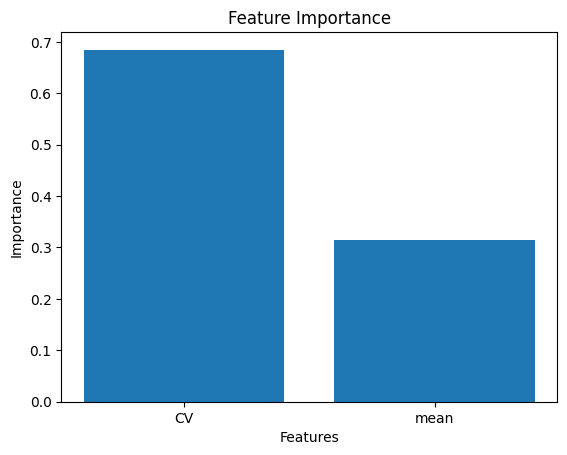

In [45]:
importances = model_full.feature_importances_
features = X.columns

feat_df = pd.DataFrame({
    'Feature': features,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

print("\nFeature Importance:\n", feat_df)

plt.figure()
plt.bar(feat_df['Feature'], feat_df['Importance'])
plt.title("Feature Importance")
plt.xlabel("Features")
plt.ylabel("Importance")
plt.show()